In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from scipy.stats import pearsonr


In [2]:
iyr= 1981 #1980
fyr=2015 # 2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)
variable='pr'
var='pr'
units='mm/day'
exp='obs'

36 41 67 78


In [3]:
sourceData='/bettik/PROJECTS/pr-regional-climate/santolam/'


In [4]:
#'/home/msantolaria/Documents/Data/'
#sourceData1= "/bettik/amoryc/MARout/GRa/spin3_ICEmask/work/"
model1='MAR'
res1=str('7kmx57m')

In [5]:
sourceData1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRp/spin2/work/monthly/'
dsM_SF= xr.open_dataset(sourceData1+'SF_mon_MARv3.14_ER5_spin2_GRp_1980-2024.nc')['SF']
dsM_RF= xr.open_dataset(sourceData1+'RF_mon_MARv3.14_ER5_spin2_GRp_1980-2024.nc')['RF']
dsM=dsM_RF+dsM_SF
#dsM

In [6]:
field1=dsM.rename({'TIME': 'time'})
#print(dsM.attrs)
#month_length = field10.time.dt.days_in_month
#field1=field10/month_length
field1=field1.sel(time=slice(str(iyr),str(fyr)))
#field1.shape

In [7]:
model3='aphro'
res3=str('0.25°x0.25°')

fileName3='APHRO_mon_MA_025deg_V1101_EXR1.1951-2015.nc'
ds3 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/aphro/monthly/'
                      +fileName3,decode_times=False)['precip']
start_date = pd.Timestamp('1951-01-01')
# Create new time index
nmonths = ds3.time.size
time_new = pd.date_range(start=start_date, periods=nmonths, freq='MS')  # 'MS' = Month Start
# Replace time in dataset
ds3['time'] = time_new

ds3=ds3.rename({'latitude':'lat','longitude':'lon'})
field3_mm_day=dom.field_dom(ds3,domain)
field3_mm_day=field3_mm_day.sel(time=slice(str(iyr),str(fyr)))

# Convert mm/day to mm/month
days_in_month = field3_mm_day['time'].dt.days_in_month
field3= field3_mm_day * days_in_month

field3.shape

(420, 20, 44)

In [8]:
model4='gpcp'
res4=str('1.0°x1.0°')

fileName4='precip_mon.gpcp_v2020_1891_2019_10.nc'
ds4= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/'
                     +model4+'/'+fileName4)['precip']
print(ds4.attrs) 
ds4=dom.reversing_lat(ds4)
#units in mm/month -> mm/day
field4=dom.field_dom(ds4,domain)

#month_length = field40.time.dt.days_in_month
#
#field4=field40/month_length
field4=field4.sel(time=slice(str(iyr),str(fyr)))
field4.shape

{'long_name': 'gpcc full data monthly product version 2020, precipitation per grid', 'units': 'mm/month', 'code': np.int32(20), 'institution': 'DWD'}


(420, 5, 11)

In [9]:
field4

<xarray.DataArray 'precip' (time: 420, lat: 5, lon: 11)> Size: 92kB
array([[[3.7210e+01, 3.5190e+01, 4.5190e+01, ..., 8.1300e+00,
         6.8800e+00, 9.0000e+00],
        [3.3600e+01, 3.9790e+01, 7.4670e+01, ..., 3.0800e+00,
         4.3700e+00, 8.3300e+00],
        [7.4820e+01, 9.5810e+01, 1.0610e+02, ..., 2.4500e+00,
         5.6800e+00, 6.9300e+00],
        [4.7310e+01, 4.3380e+01, 3.2440e+01, ..., 4.9000e+00,
         5.1400e+00, 3.0700e+00],
        [3.0620e+01, 3.1650e+01, 3.3780e+01, ..., 5.6600e+00,
         4.7400e+00, 2.5600e+00]],

       [[5.2990e+01, 5.3400e+01, 7.0010e+01, ..., 6.6600e+00,
         6.6600e+00, 2.3900e+00],
        [3.8150e+01, 5.7590e+01, 1.0449e+02, ..., 1.5700e+00,
         5.1000e-01, 2.0000e-01],
        [1.0707e+02, 1.3412e+02, 1.8604e+02, ..., 5.1000e-01,
         2.5000e-01, 3.5000e-01],
        [1.1352e+02, 7.0320e+01, 5.8610e+01, ..., 2.4500e+00,
         6.4000e-01, 7.1000e-01],
        [9.1940e+01, 8.3640e+01, 7.0780e+01, ..., 1.2200e+01,
...
         2.8300e+00, 4.1000e-01],
        [6.1960e+01, 5.0950e+01, 5.7310e+01, ..., 1.0300e+00,
         2.6000e-01, 1.0000e-02],
        [6.6190e+01, 1.0125e+02, 9.2690e+01, ..., 0.0000e+00,
         1.2000e-01, 2.8000e-01],
        [6.1310e+01, 4.5570e+01, 4.0030e+01, ..., 7.1000e-01,
         1.9000e-01, 3.2000e-01],
        [4.5470e+01, 3.9430e+01, 4.6020e+01, ..., 8.0500e+00,
         7.6100e+00, 3.0300e+00]],

       [[1.0520e+01, 1.7340e+01, 2.8250e+01, ..., 6.5200e+00,
         9.2200e+00, 4.7000e+00],
        [1.1130e+01, 1.6080e+01, 3.5470e+01, ..., 4.5800e+00,
         1.8300e+00, 1.8800e+00],
        [3.3560e+01, 4.9910e+01, 5.3780e+01, ..., 9.2000e-01,
         8.0000e-02, 3.7000e-01],
        [2.3540e+01, 2.5030e+01, 2.6380e+01, ..., 1.1000e-01,
         1.2000e-01, 3.2000e-01],
        [1.1920e+01, 1.8880e+01, 3.3060e+01, ..., 4.4100e+00,
         4.6500e+00, 2.5400e+00]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1981-01-01 1981-02-01 ... 2015-12-01
  * lon      (lon) float64 88B 67.5 68.5 69.5 70.5 71.5 ... 74.5 75.5 76.5 77.5
  * lat      (lat) float64 40B 36.5 37.5 38.5 39.5 40.5
Attributes:
    long_name:    gpcc full data monthly product version 2020, precipitation ...
    units:        mm/month
    code:         20
    institution:  DWD

In [10]:
field4.coords

Coordinates:
  * time     (time) datetime64[ns] 3kB 1981-01-01 1981-02-01 ... 2015-12-01
  * lon      (lon) float64 88B 67.5 68.5 69.5 70.5 71.5 ... 74.5 75.5 76.5 77.5
  * lat      (lat) float64 40B 36.5 37.5 38.5 39.5 40.5

In [11]:
model5='cru'
res5=str('0.5°x0.5°')

fileName5='cru_ts4.05.1901.2020.pre.dat.nc'
ds5 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/'+model5+'/'+fileName5)['pre']
print(ds5.attrs)

#units in mm/month -> mm/day
field5=dom.field_dom(ds5,domain)
#month_length5 = field50.time.dt.days_in_month
#
#field5=field50/month_length5
field5=field5.sel(time=slice(str(iyr),str(fyr)))
field5.shape

{'long_name': 'precipitation', 'units': 'mm/month', 'correlation_decay_distance': np.float32(450.0)}


(420, 10, 22)

In [12]:
field5

<xarray.DataArray 'pre' (time: 420, lat: 10, lon: 22)> Size: 370kB
array([[[ 45.9       ,  51.4       ,  50.7       , ...,  55.600002  ,
          52.        ,  48.8       ],
        [ 35.8       ,  40.7       ,  47.3       , ...,  40.7       ,
          44.600002  ,  37.600002  ],
        [ 32.        ,  41.9       ,  48.100002  , ...,  23.2       ,
          12.7       ,  10.3       ],
        ...,
        [ 40.3       ,  54.100002  ,  64.4       , ...,   7.        ,
           4.6       ,   2.9       ],
        [ 42.9       ,  38.4       ,  37.8       , ...,  12.900001  ,
           8.5       ,   6.1       ],
        [ 35.600002  ,  36.2       ,  35.3       , ...,  12.1       ,
          12.8       ,   9.6       ]],

       [[ 74.4       ,  80.3       ,  81.9       , ...,  13.5       ,
          12.3       ,   9.1       ],
        [ 54.100002  ,  59.7       ,  70.700005  , ...,  10.        ,
           8.        ,   5.9       ],
        [ 44.4       ,  57.600002  ,  70.5       , ...,   5.3       ,
           2.5       ,   1.8000001 ],
...
        [ 63.600002  ,  89.        ,  95.4       , ...,   3.1000001 ,
           1.5       ,   2.2       ],
        [ 64.3       ,  61.8       ,  62.600002  , ...,   6.        ,
           4.4       ,   4.4       ],
        [ 45.3       ,  57.3       ,  46.        , ...,  13.2       ,
          10.5       ,   9.6       ]],

       [[ 25.5       ,  25.7       ,  23.300001  , ...,  20.2       ,
          26.5       ,  30.6       ],
        [ 17.800001  ,  18.800001  ,  19.2       , ...,  18.        ,
          23.6       ,  26.300001  ],
        [ 16.        ,  18.2       ,  20.6       , ...,   9.5       ,
           5.8       ,   5.4       ],
        ...,
        [ 28.9       ,  40.7       ,  40.7       , ...,   0.7       ,
           0.90000004,   1.1       ],
        [ 32.600002  ,  33.        ,  31.9       , ...,   5.7000003 ,
           4.3       ,   3.6000001 ],
        [ 27.800001  ,  35.3       ,  34.2       , ...,  11.6       ,
          10.2       ,   8.6       ]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 88B 67.25 67.75 68.25 68.75 ... 76.75 77.25 77.75
  * lat      (lat) float32 40B 36.25 36.75 37.25 37.75 ... 39.75 40.25 40.75
  * time     (time) datetime64[ns] 3kB 1981-01-16 1981-02-15 ... 2015-12-16
Attributes:
    long_name:                   precipitation
    units:                       mm/month
    correlation_decay_distance:  450.0

In [13]:
model6='chirps'
res6='0.05°x0.05°'
fileName6='chirps-v2.0.monthly.nc'
ds6 = xr.open_dataset(sourceData+model6+'/'+fileName6)['precip']
ds6=ds6.rename({'latitude':'lat','longitude':'lon'})
field6=dom.field_dom(ds6,domain)


print(field6.shape)

(531, 100, 220)


In [14]:
field6

<xarray.DataArray 'precip' (time: 531, lat: 100, lon: 220)> Size: 47MB
array([[[48.16716  , 48.06145  , 47.82819  , ..., 16.908018 ,
         15.261884 , 14.133849 ],
        [49.075897 , 49.05452  , 50.256824 , ..., 16.02953  ,
         14.8828125, 14.217459 ],
        [53.871292 , 53.788185 , 49.902637 , ..., 16.67226  ,
         15.509744 , 14.939869 ],
        ...,
        [26.87648  , 26.66181  , 27.196583 , ...,  2.2314086,
          2.198823 ,  1.690921 ],
        [26.775805 , 26.518047 , 26.317322 , ...,  1.7659523,
          1.7212954,  1.6772063],
        [26.069946 , 25.766272 , 26.198868 , ...,  1.7532327,
          1.7144885,  1.6609434]],

       [[70.236755 , 71.314186 , 71.7143   , ..., 19.168444 ,
         18.135061 , 17.610147 ],
        [65.714615 , 66.758224 , 68.08676  , ..., 17.49435  ,
         16.433956 , 15.33308  ],
        [64.86342  , 65.84293  , 70.202484 , ..., 16.260296 ,
         15.192438 , 15.078248 ],
...
        [22.46246  , 22.599953 , 23.506332 , ...,  3.0693636,
          3.014594 ,  2.9320314],
        [23.253254 , 22.533073 , 23.207573 , ...,  3.074812 ,
          3.0577788,  2.9071026],
        [21.748846 , 22.111677 , 22.471865 , ...,  3.0053449,
          3.0921397,  2.905395 ]],

       [[56.176716 , 59.390766 , 58.041355 , ..., 28.966812 ,
         27.812023 , 24.975029 ],
        [52.34113  , 61.60546  , 58.5349   , ..., 26.276691 ,
         25.577686 , 24.596935 ],
        [58.225166 , 60.471783 , 61.85607  , ..., 24.24836  ,
         22.398384 , 22.161322 ],
        ...,
        [28.862856 , 30.457394 , 30.248602 , ..., 10.557101 ,
          9.669617 ,  8.452001 ],
        [30.084106 , 28.956844 , 29.718779 , ..., 10.674074 ,
         10.164293 ,  8.48581  ],
        [29.154303 , 28.831835 , 29.737171 , ...,  9.88394  ,
          9.937598 ,  8.04279  ]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 400B 36.02 36.07 36.12 36.17 ... 40.87 40.92 40.97
  * lon      (lon) float32 880B 67.02 67.07 67.12 67.18 ... 77.88 77.92 77.98
  * time     (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2025-03-01
Attributes:
    units:               mm/month
    standard_name:       convective precipitation rate
    long_name:           Climate Hazards group InfraRed Precipitation with St...
    time_step:           month
    geostatial_lat_min:  -50.0
    geostatial_lat_max:  50.0
    geostatial_lon_min:  -180.0
    geostatial_lon_max:  180.0

In [15]:
time_min = pd.to_datetime(ds6['time'].max().values)
print("Time min :", time_min)

Time min : 2025-03-01 00:00:00


In [16]:
model7='HARv2'
res7='10kmx10km'
#variable='prcp'
fileName7='HARv2_mon_d10km_d_2d_prcp_1980-2023.nc'
ds7_raw0= xr.open_dataset(sourceData+'/'+model7+'/'+fileName7)['prcp']
ds7_raw=ds7_raw0*24 #mm/h
# Calculate days in each month
days_in_month7= ds7_raw['time'].dt.days_in_month
# Convert to mm/month
ds7= ds7_raw* days_in_month7
def xy_sel_dom(ds,domain):
    latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
        print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

# Apply mask (non-NaN where the condition is True)
#hgt_subset = hgt.where(mask, drop=True)
field7=xy_sel_dom(ds7.sel(time=slice(str(iyr),str(fyr))),domain)

time
lon
lat
west_east
south_north


In [17]:

## SAME ANALYSIS BUT FOR multiple data sets(at the same time): lists

dsList=[field1,
        field3,field4,field5,
        field6,field7]
modelList=[model1,
           model3,model4,model5,
           model6,model7]
resList=[res1,
         res3,res4,res5,
         res6,res7]
nameList=list(zip(modelList,resList))

In [18]:
print(nameList)
print(len(nameList))

[('MAR', '7kmx57m'), ('aphro', '0.25°x0.25°'), ('gpcp', '1.0°x1.0°'), ('cru', '0.5°x0.5°'), ('chirps', '0.05°x0.05°'), ('HARv2', '10kmx10km')]
6


In [19]:
###Annual cycle

avgList=[]
for i,elem in enumerate(dsList):
    if i==0:
        avg0=elem.mean(dim='X').mean(dim='Y')
    elif i in [1,2,3,4]:
        avg0=elem.mean(dim='lon').mean(dim='lat')
    elif i in [5]:
        avg0=elem.mean(dim='south_north').mean(dim='west_east')
    avgList.append(avg0)
    
annualCycleList = []
for da in avgList:
    # Compute the climatological mean for each month
    clim = da.groupby('time.month').mean('time')
    annualCycleList.append(clim)


In [20]:
plotsDir='/bettik/PROJECTS/pr-regional-climate/fainx/figures'

/tmp/ipykernel_1818130/2675170731.py:8: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(xmonths, annualCycleList[0], 'b',linestyle='-',marker='o',label=nameList[0])
/tmp/ipykernel_1818130/2675170731.py:10: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(xmonths, annualCycleList[1], 'orange',linestyle=':',marker='o',label=nameList[1])
/tmp/ipykernel_1818130/2675170731.py:11: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(xm

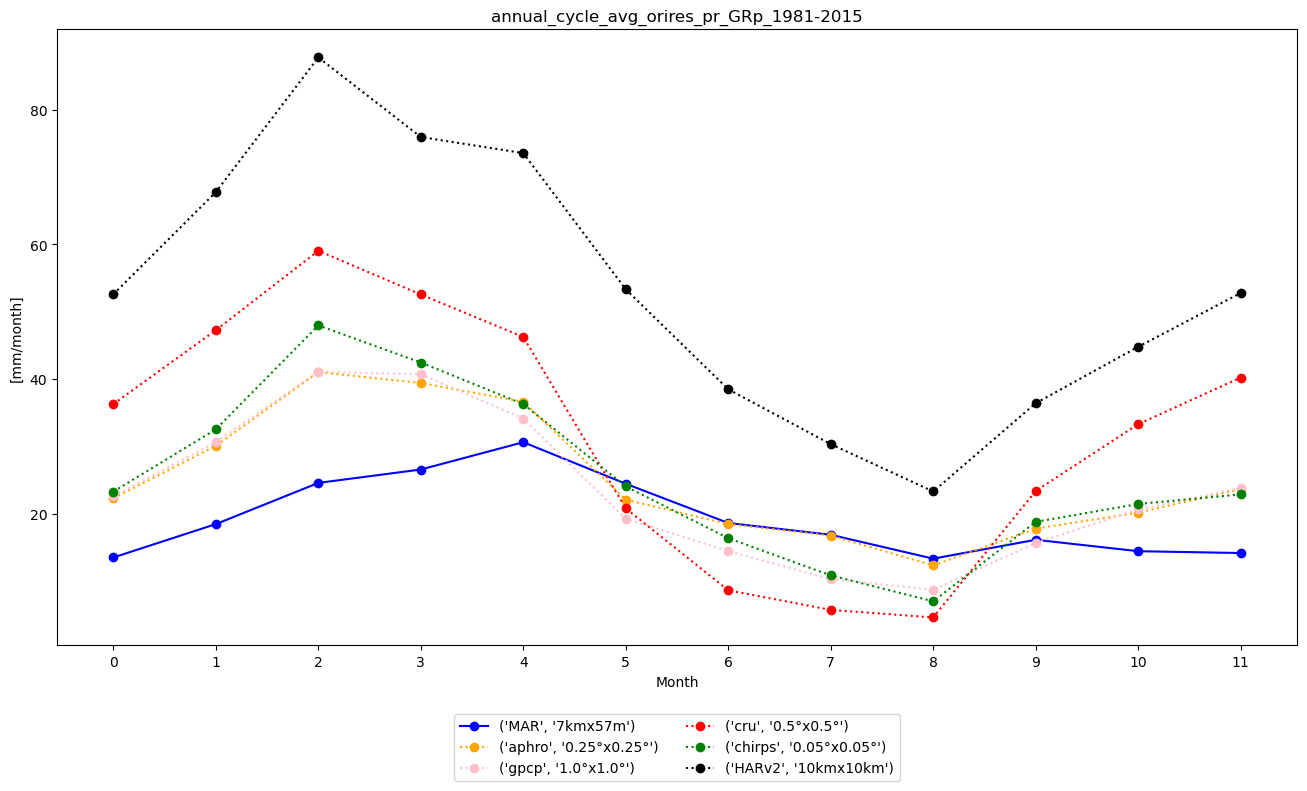

In [21]:

plotname="annual_cycle_"+"avg_orires_"+ var+'_GRp_'+str(iyr)+'-'+str(fyr)

xmonths=np.arange(0,12,1)

fig, ax = plt.subplots(figsize=(16, 8))
my_ticks=xmonths

ax.plot(xmonths, annualCycleList[0], 'b',linestyle='-',marker='o',label=nameList[0])

ax.plot(xmonths, annualCycleList[1], 'orange',linestyle=':',marker='o',label=nameList[1])
ax.plot(xmonths, annualCycleList[2], 'pink',linestyle=':',marker='o',label=nameList[2])
ax.plot(xmonths, annualCycleList[3], 'red',linestyle=':',marker='o',label=nameList[3])

ax.plot(xmonths, annualCycleList[4], 'green',linestyle=':',marker='o',label=nameList[4])
ax.plot(xmonths, annualCycleList[5], 'black',linestyle=':',marker='o',label=nameList[5])
#ax.plot(xmonths, annualCycleList[5], 'red',linestyle=':',marker='o',label=modelList[6]+'['+ resList[6]+']')

#ax.axhline(0, color='k')
#ax.set_ylim(0, 1)
ax.set_xlabel('Month')
ax.set_ylabel('[mm/month]')
ax.set_title(plotname)
freq=5
plt.xticks(xmonths,my_ticks,)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=2)

plt.savefig(plotsDir+plotname+'.png',format='png')
plt.show()


/tmp/ipykernel_1818130/411720024.py:16: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax1.plot(xmonths, annualCycleList[0], 'b', linestyle='-', marker='o', label=nameList[0])
/tmp/ipykernel_1818130/411720024.py:17: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax1.plot(xmonths, annualCycleList[1], 'orange', linestyle='-', marker='o', label=nameList[1])
/tmp/ipykernel_1818130/411720024.py:18: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax1.

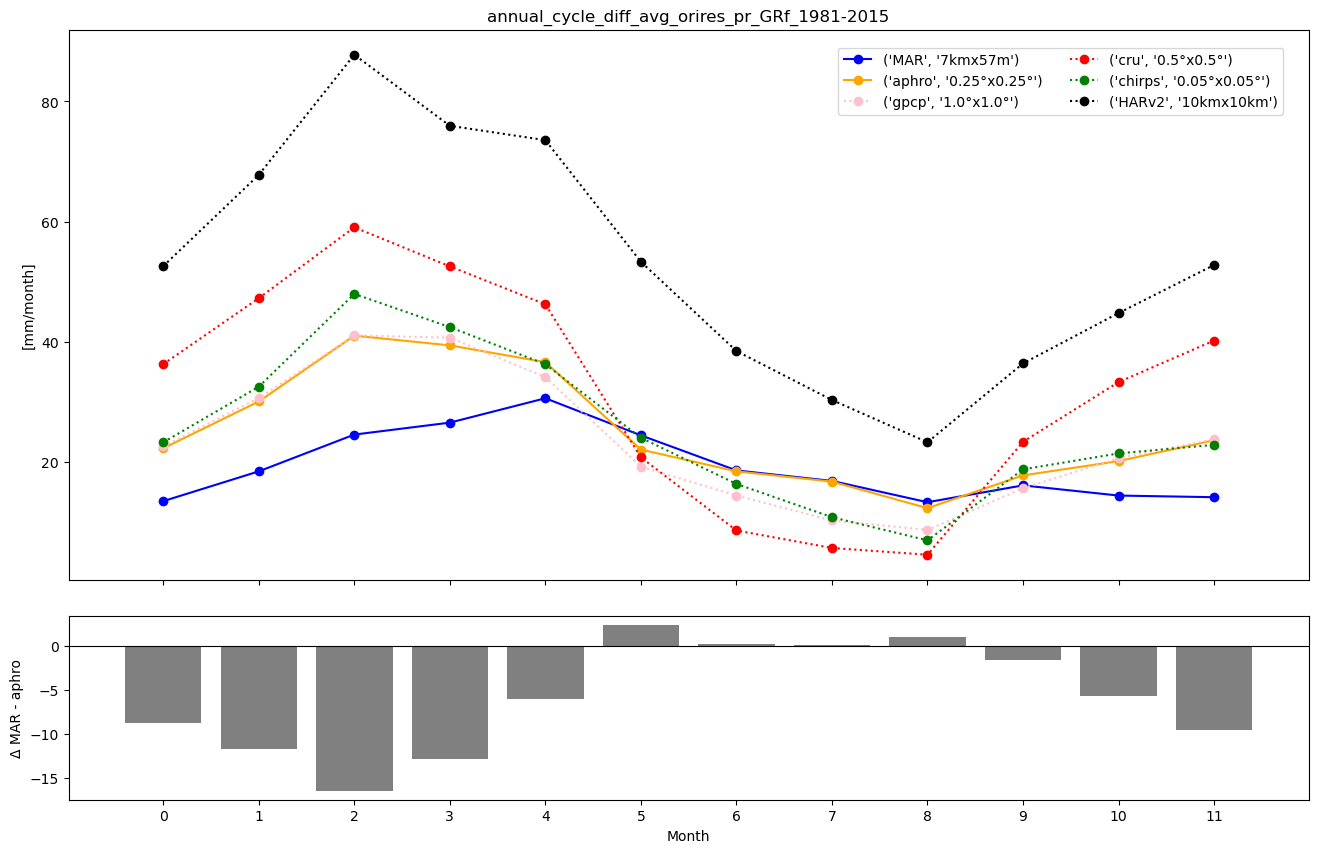

In [22]:
xmonths = np.arange(0, 12, 1)
my_ticks = xmonths


plotname="annual_cycle_diff_"+"avg_orires_"+ var+"_"+domain+'_'+str(iyr)+'-'+str(fyr)

# Compute difference
diff = np.array(annualCycleList[0]) - np.array(annualCycleList[1])

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 10), sharex=True, 
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.1}
)

# --- Main line plot ---
ax1.plot(xmonths, annualCycleList[0], 'b', linestyle='-', marker='o', label=nameList[0])
ax1.plot(xmonths, annualCycleList[1], 'orange', linestyle='-', marker='o', label=nameList[1])
ax1.plot(xmonths, annualCycleList[2], 'pink', linestyle=':', marker='o', label=nameList[2])
ax1.plot(xmonths, annualCycleList[3], 'red', linestyle=':', marker='o', label=nameList[3])
ax1.plot(xmonths, annualCycleList[4], 'green', linestyle=':', marker='o', label=nameList[4])
ax1.plot(xmonths, annualCycleList[5], 'black', linestyle=':', marker='o', label=nameList[5])

ax1.set_ylabel('[mm/month]')
ax1.set_title(plotname)
ax1.legend(loc='upper center', bbox_to_anchor=(0.8, 0.98), ncol=2)

# --- Difference bar plot ---
ax2.bar(xmonths, diff, color='gray')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Δ ' + nameList[0][0] + ' - ' + nameList[1][0])
ax2.set_xlabel('Month')
ax2.set_xticks(xmonths)
ax2.set_xticklabels(my_ticks)

#plt.tight_layout()
plt.savefig(plotsDir+plotname+'.png',format='png')
plt.show()


In [53]:
valsList_DJF = [climb.seasonal_selection(elem, 'DJF', iyr, fyr)[0] for elem in dsList]
valsList_MAM = [climb.seasonal_selection(elem, 'MAM', iyr, fyr)[0] for elem in dsList]
valsList_JJA = [climb.seasonal_selection(elem, 'JJA', iyr, fyr)[0] for elem in dsList]
valsList_SON = [climb.seasonal_selection(elem, 'SON', iyr, fyr)[0] for elem in dsList]


(D- 1981  JF- 1982  to D- 2015 JF- 2016
(D- 1981  JF- 1982  to D- 2015 JF- 2016
(D- 1981  JF- 1982  to D- 2015 JF- 2016
(D- 1981  JF- 1982  to D- 2015 JF- 2016
(D- 1981  JF- 1982  to D- 2015 JF- 2016
(D- 1981  JF- 1982  to D- 2015 JF- 2016


In [54]:
ts_seasonList_DJF=[]
ts_seasonList_MAM=[]
ts_seasonList_JJA=[]
ts_seasonList_SON=[]

for i in np.arange(0,len(dsList),1):
    if i==0:
        ts_season_DJF=valsList_DJF[i].mean(dim='X').mean(dim='Y')
        ts_season_MAM=valsList_MAM[i].mean(dim='X').mean(dim='Y')        
        ts_season_JJA=valsList_JJA[i].mean(dim='X').mean(dim='Y')
        ts_season_SON=valsList_SON[i].mean(dim='X').mean(dim='Y')
    elif i in [1,2,3,4]:
        ts_season_DJF=climb.spatial_average(valsList_DJF[i])
        ts_season_MAM=climb.spatial_average(valsList_MAM[i])
        ts_season_JJA=climb.spatial_average(valsList_JJA[i])        
        ts_season_SON=climb.spatial_average(valsList_SON[i])
    elif i in [5]:
        ts_season_DJF=valsList_DJF[i].mean(dim='south_north').mean(dim='west_east')
        ts_season_MAM=valsList_MAM[i].mean(dim='south_north').mean(dim='west_east')
        ts_season_JJA=valsList_JJA[i].mean(dim='south_north').mean(dim='west_east')
        ts_season_SON=valsList_SON[i].mean(dim='south_north').mean(dim='west_east')
    ts_seasonList_DJF.append(ts_season_DJF)
    ts_seasonList_MAM.append(ts_season_MAM)
    ts_seasonList_JJA.append(ts_season_JJA)
    ts_seasonList_SON.append(ts_season_SON)


In [55]:
colorList=['b','orange',  'pink', 'red',  'green', 'black']

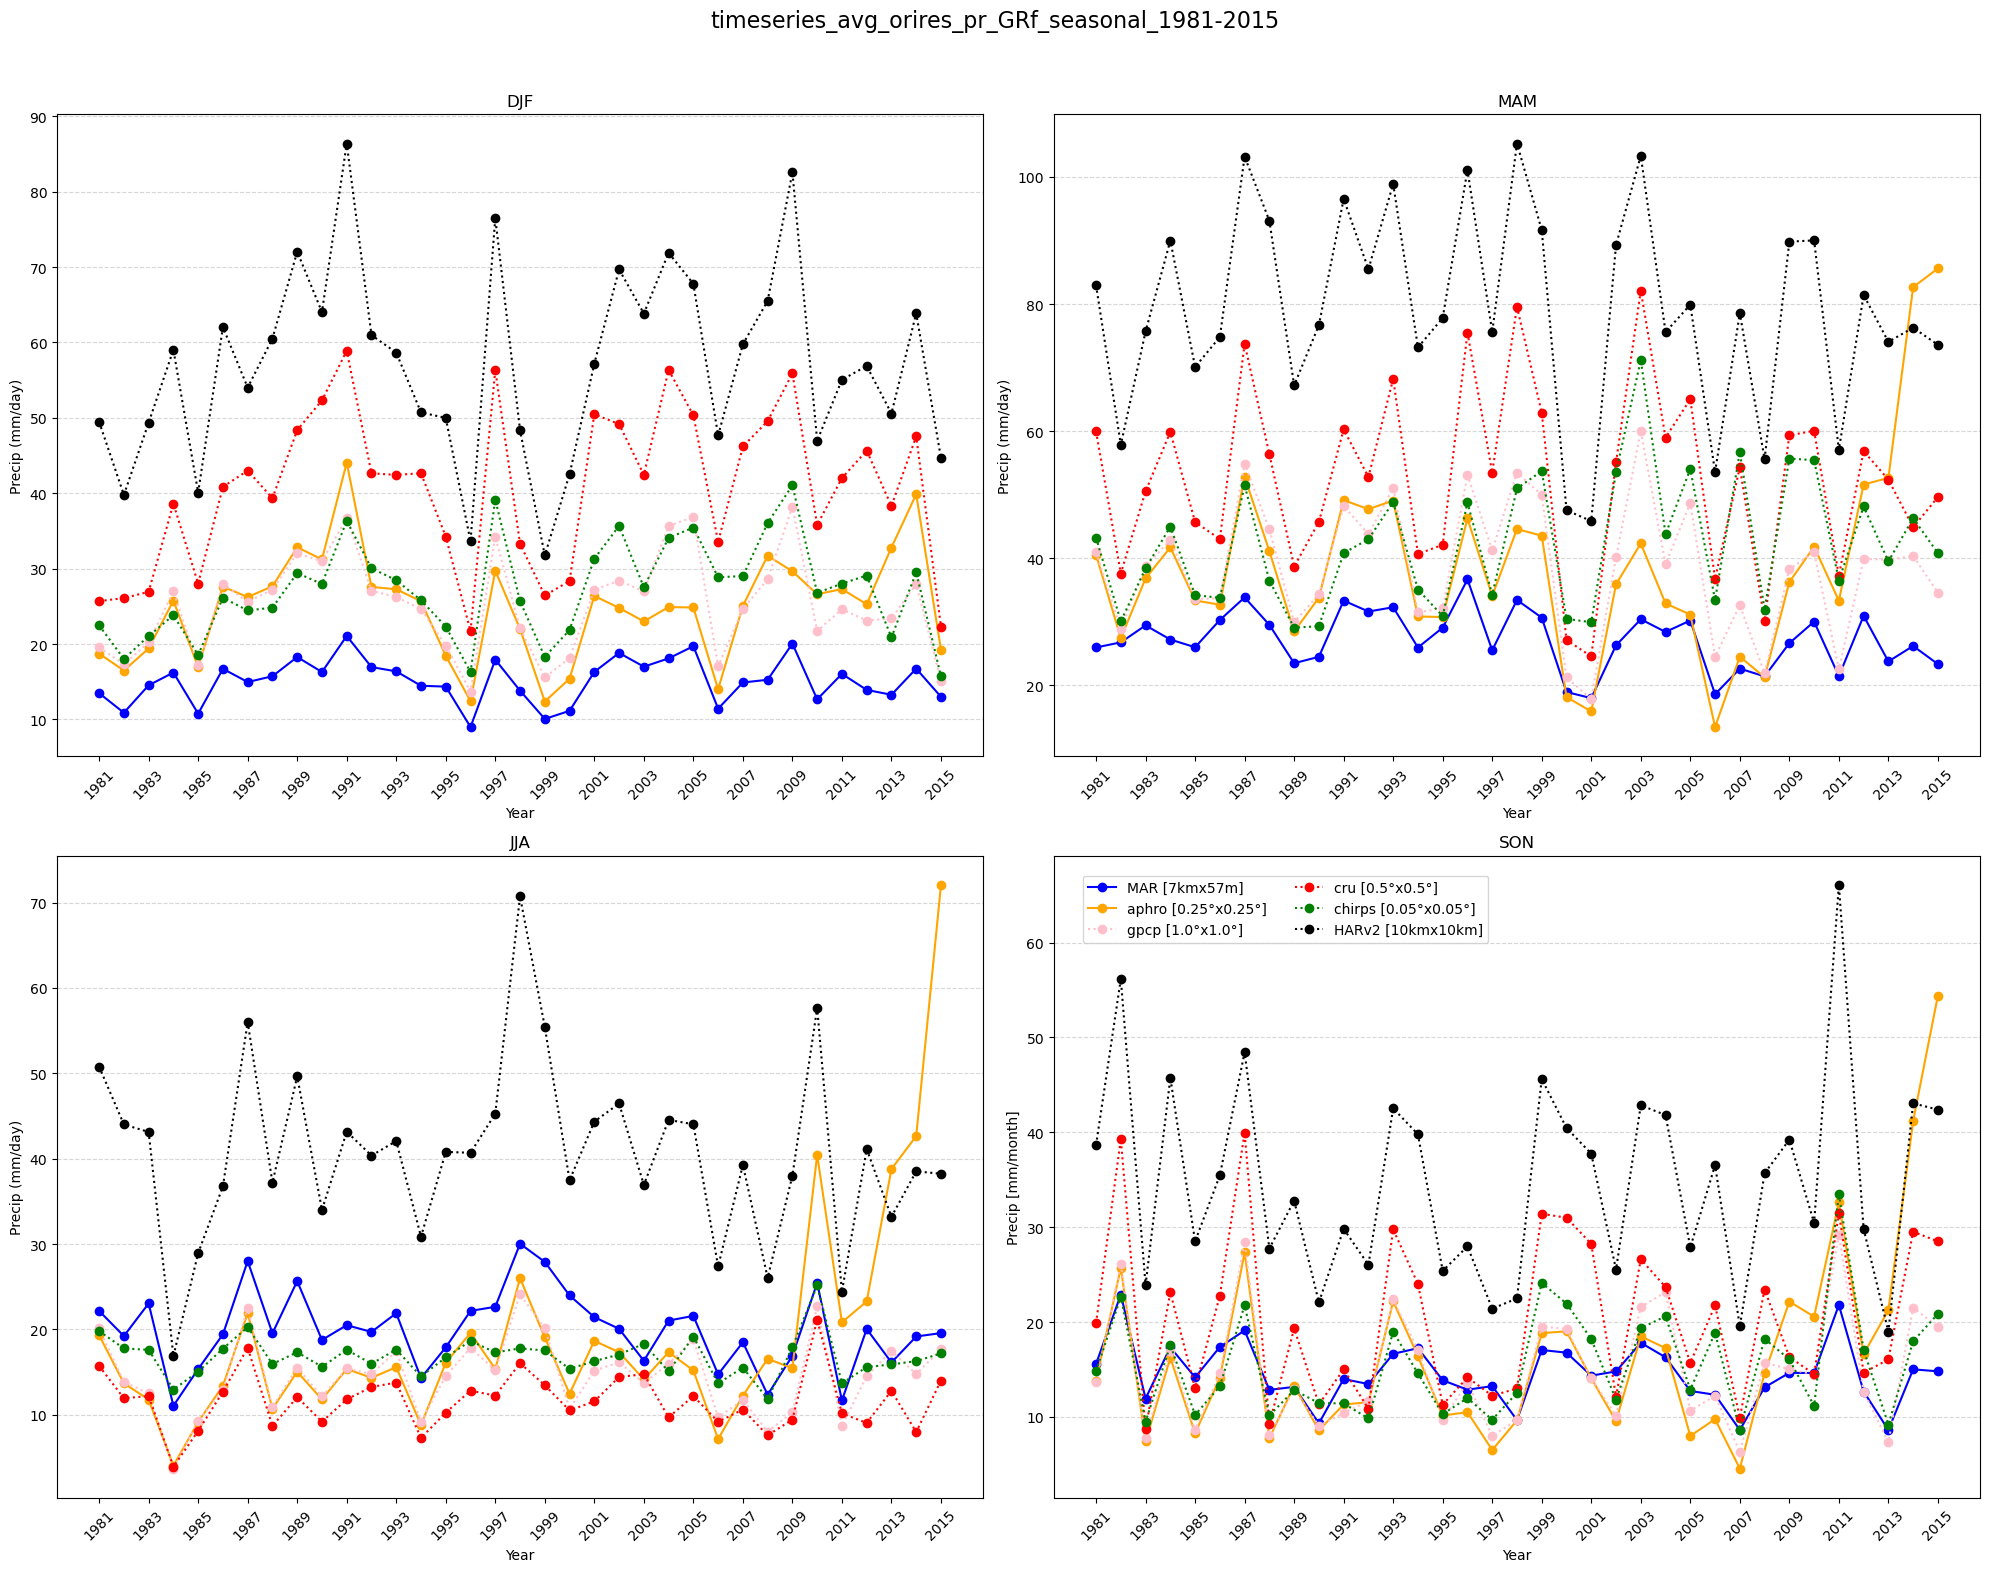

In [56]:
plotname="timeseries_"+"avg_orires_"+ var+"_"+domain+'_seasonal_'+str(iyr)+'-'+str(fyr)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

xd = np.arange(0, len(ts_seasonList_DJF[0]), 1)
my_ticks = xd + iyr

# DJF 
ax1.plot(xd, ts_seasonList_DJF[0], color=colorList[0],marker='o',linestyle='-', label=f"{modelList[0]} [{resList[0]}]")
ax1.plot(xd, ts_seasonList_DJF[1], color=colorList[1], linestyle='-', marker='o', label=f"{modelList[1]} [{resList[1]}]")
ax1.plot(xd, ts_seasonList_DJF[2], color=colorList[2], linestyle=':', marker='o', label=f"{modelList[2]} [{resList[2]}]")
ax1.plot(xd, ts_seasonList_DJF[3], color=colorList[3], linestyle=':', marker='o', label=f"{modelList[3]} [{resList[3]}]")
ax1.plot(xd, ts_seasonList_DJF[4], color=colorList[4], linestyle=':', marker='o', label=f"{modelList[4]} [{resList[4]}]")
ax1.plot(xd, ts_seasonList_DJF[5], color=colorList[5], linestyle=':', marker='o', label=f"{modelList[5]} [{resList[5]}]")
#ax1.plot(xd, ts_seasonList_DJF[6], color='orange', linestyle=':', marker='o', label=f"{modelList[6]} [{resList[6]}]")


ax1.set_title('DJF')
#ax1.set_ylim(0, 3)
ax1.set_xticks(xd[::2])
ax1.set_xticklabels(my_ticks[::2], rotation=45)
ax1.set_ylabel('Precip (mm/day)')
ax1.set_xlabel('Year')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
#ax1.legend()

# MAM 
ax2.plot(xd, ts_seasonList_MAM[0],color=colorList[0], linestyle='-', marker='o', label=f"{modelList[0]} [{resList[0]}]")
ax2.plot(xd, ts_seasonList_MAM[1], color=colorList[1], linestyle='-', marker='o', label=f"{modelList[1]} [{resList[1]}]")
ax2.plot(xd, ts_seasonList_MAM[2], color=colorList[2], linestyle=':', marker='o',label=f"{modelList[2]} [{resList[2]}]")
ax2.plot(xd, ts_seasonList_MAM[3], color=colorList[3], linestyle=':', marker='o',label=f"{modelList[3]} [{resList[3]}]")
ax2.plot(xd, ts_seasonList_MAM[4],color=colorList[4], linestyle=':', marker='o', label=f"{modelList[4]} [{resList[4]}]")
ax2.plot(xd, ts_seasonList_MAM[5], color=colorList[5], linestyle=':', marker='o', label=f"{modelList[5]} [{resList[5]}]")
#ax2.plot(xd, ts_seasonList_MAM[6], color='orange', linestyle=':', marker='o', label=f"{modelList[6]} [{resList[6]}]")

ax2.set_title('MAM')
#ax2.set_ylim(0, 3)
ax2.set_xticks(xd[::2])
ax2.set_xticklabels(my_ticks[::2], rotation=45)
ax2.set_ylabel('Precip (mm/day)')
ax2.set_xlabel('Year')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)
#ax2.legend()

# JJA
ax3.plot(xd, ts_seasonList_JJA[0], color=colorList[0], linestyle='-', marker='o', label=f"{modelList[0]} [{resList[0]}]")
ax3.plot(xd, ts_seasonList_JJA[1],color=colorList[1], linestyle='-', marker='o',label=f"{modelList[1]} [{resList[1]}]")
ax3.plot(xd, ts_seasonList_JJA[2],color=colorList[2], linestyle=':', marker='o',label=f"{modelList[2]} [{resList[2]}]")
ax3.plot(xd, ts_seasonList_JJA[3], color=colorList[3], linestyle=':', marker='o', label=f"{modelList[3]} [{resList[3]}]")

ax3.plot(xd, ts_seasonList_JJA[4], color=colorList[4], linestyle=':', marker='o',label=f"{modelList[4]} [{resList[4]}]")
ax3.plot(xd, ts_seasonList_JJA[5], color=colorList[5], linestyle=':', marker='o',label=f"{modelList[5]} [{resList[5]}]")
#ax3.plot(xd, ts_seasonList_JJA[6], color='orange', linestyle=':', marker='o', label=f"{modelList[6]} [{resList[6]}]")

ax3.set_title('JJA')
#ax3.set_ylim(0, 3)
ax3.set_xticks(xd[::2])
ax3.set_xticklabels(my_ticks[::2], rotation=45)
ax3.set_ylabel('Precip (mm/day)')
ax3.set_xlabel('Year')
ax3.grid(True, axis='y', linestyle='--', alpha=0.5)
#ax3.legend()

#SON
ax4.plot(xd, ts_seasonList_SON[0],color=colorList[0], linestyle='-',marker='o', label=f"{modelList[0]} [{resList[0]}]")
ax4.plot(xd, ts_seasonList_SON[1], color=colorList[1], linestyle='-', marker='o', label=f"{modelList[1]} [{resList[1]}]")
ax4.plot(xd, ts_seasonList_SON[2], color=colorList[2], linestyle=':', marker='o', label=f"{modelList[2]} [{resList[2]}]")
ax4.plot(xd, ts_seasonList_SON[3], color=colorList[3], linestyle=':', marker='o', label=f"{modelList[3]} [{resList[3]}]")

ax4.plot(xd, ts_seasonList_SON[4], color=colorList[4], linestyle=':', marker='o', label=f"{modelList[4]} [{resList[4]}]")
ax4.plot(xd, ts_seasonList_SON[5], color=colorList[5], linestyle=':', marker='o', label=f"{modelList[5]} [{resList[5]}]")
#ax4.plot(xd, ts_seasonList_SON[6], color='orange', linestyle=':', marker='o', label=f"{modelList[6]} [{resList[6]}]")


ax4.set_title('SON')
#ax4.set_ylim(0, 3)
ax4.set_xticks(xd[::2])
ax4.set_xticklabels(my_ticks[::2], rotation=45)
ax4.set_ylabel('Precip [mm/month]')
ax4.set_xlabel('Year')
ax4.grid(True, axis='y', linestyle='--', alpha=0.5)
#ax4.legend()
ax4.legend(loc='upper center', bbox_to_anchor=(0.25, 0.98), ncol=2)

fig.suptitle(plotname, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(plotsDir+plotname+'.png',format='png')


plt.show()

In [ ]:
ts_seasonList_DJF

In [57]:
##As in Khada et al:
#Four different performance indicators are used to evaluate
#daily mean values, of the different reanalysis variables listed: 
#Pearson correlation coefficient r: r is a measure of linear correlation between reanalyzed and observed data.
#bias: bias is the mean value of the difference between those two sets of data and is also called systematic error 
#standard deviation (SD): SD is the dispersion of the error
#and root-mean-square error (RMSE): the standard deviation of the error

#print('STATS:', modelList[1]+'['+ resList[1]+']')
ts_seasonList=ts_seasonList_DJF
obs =ts_seasonList[1] #np.array([3.0, -0.5, 2.0, 7.0])

#print(modelList[0]+'['+ resList[0]+']')
pred = ts_seasonList[0]#np.array([2.5, 0.0, 2.1, 7.8])

corr_coef, _ = pearsonr(obs, pred)
print('DIF[',modelList[0]+'['+ resList[0]+'] -',modelList[1]+'['+ resList[1]+']]')
bias = np.mean(pred - obs)

# Standard deviation of errors
std_dev = np.std(pred - obs)

# 4. RMSE (Root Mean Square Error)
rmse = np.sqrt(np.mean((pred - obs) ** 2))

# Print results
print("Correlation Coefficient:'",corr_coef)
print("Bias:",bias.values)
print("Standard Deviation:",std_dev.values)
print("RMSE:", rmse.values)


DIF[ MAR[7kmx57m] - aphro[0.25°x0.25°]]
Correlation Coefficient:' 0.7472271649421005
Bias: -9.804983428319195
Standard Deviation: 5.183202169802251
RMSE: 11.090684593957974


In [58]:
len(ts_seasonList)

6

In [59]:
ts_seasonList=ts_seasonList_DJF

rList=[]
biasList=[]
std_devList=[]
rmseList=[]

pred = ts_seasonList[0]#np.array([2.5, 0.0, 2.1, 7.8])
for i in np.arange(1,len(ts_seasonList),1):
    obs =ts_seasonList[i] 
    corr_coef, _ = pearsonr(obs, pred)
    bias = np.mean(pred - obs)
    std_dev = np.std(pred - obs)
    rmse = np.sqrt(np.mean((pred - obs) ** 2))
    rList.append(round(corr_coef,3))
    biasList.append(round(float(bias.values),3))
    std_devList.append(round(float(std_dev.values),3))
    rmseList.append(round(float(rmse.values),3))

modelResList=zip(modelList[1:],resList[1:])
# Create the DataFrame
df = pd.DataFrame({
    "Model_Res": modelResList,
    "Corr": rList,
    "Bias": biasList,
    "Std_Dev": std_devList,
    "RMSE": rmseList
})

# Display the DataFrame
print('DJF')
print(df)

DJF
               Model_Res   Corr    Bias  Std_Dev    RMSE
0   (aphro, 0.25°x0.25°)  0.747  -9.805    5.183  11.091
1      (gpcp, 1.0°x1.0°)  0.936 -10.076    3.873  10.795
2       (cru, 0.5°x0.5°)  0.858 -25.481    7.998  26.707
3  (chirps, 0.05°x0.05°)  0.817 -11.997    4.313  12.749
4     (HARv2, 10kmx10km)  0.950 -41.823    9.903  42.979


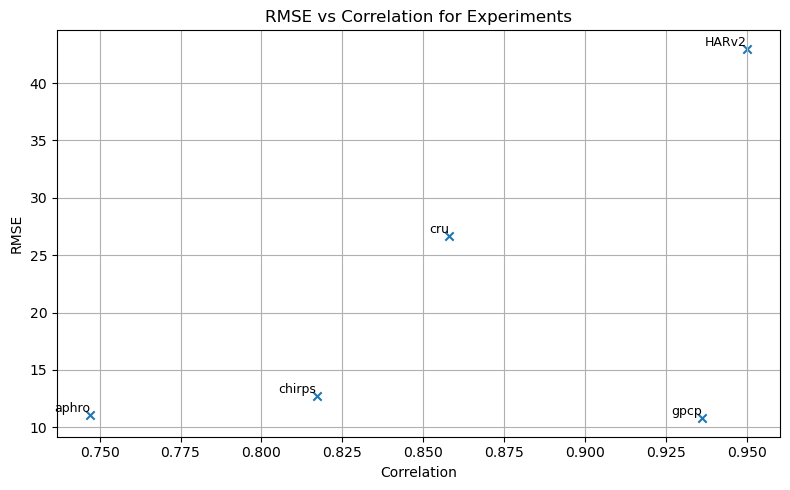

In [60]:
labels=modelList[1:]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(rList, rmseList, marker="x")

# Add experiment labels next to each point
for x, y, label in zip(rList, rmseList, labels):
    ax.text(x, y, label, fontsize=9, ha="right", va="bottom")

ax.set_xlabel("Correlation")
ax.set_ylabel("RMSE")
ax.set_title("RMSE vs Correlation for Experiments")
ax.grid(True)
fig.tight_layout()

In [61]:
print("MAM")
ts_seasonList=ts_seasonList_MAM

rList=[]
biasList=[]
std_devList=[]
rmseList=[]

pred = ts_seasonList[0]#np.array([2.5, 0.0, 2.1, 7.8])
for i in np.arange(1,len(ts_seasonList),1):
    obs =ts_seasonList[i] 
    corr_coef, _ = pearsonr(obs, pred)
    bias = np.mean(pred - obs)
    std_dev = np.std(pred - obs)
    rmse = np.sqrt(np.mean((pred - obs) ** 2))
    rList.append(round(corr_coef,3))
    biasList.append(round(float(bias.values),3))
    std_devList.append(round(float(std_dev.values),3))
    rmseList.append(round(float(rmse.values),3))

modelResList=zip(modelList[1:],resList[1:])
# Create the DataFrame
df = pd.DataFrame({
    "Model_Res": modelResList,
    "Corr": rList,
    "Bias": biasList,
    "Std_Dev": std_devList,
    "RMSE": rmseList
})

print(df)

MAM
               Model_Res   Corr    Bias  Std_Dev    RMSE
0   (aphro, 0.25°x0.25°)  0.419 -11.753   13.698  18.049
1      (gpcp, 1.0°x1.0°)  0.853 -11.325    6.721  13.169
2       (cru, 0.5°x0.5°)  0.795 -25.378   10.703  27.542
3  (chirps, 0.05°x0.05°)  0.500 -15.195    8.734  17.526
4     (HARv2, 10kmx10km)  0.853 -51.868   12.013  53.241


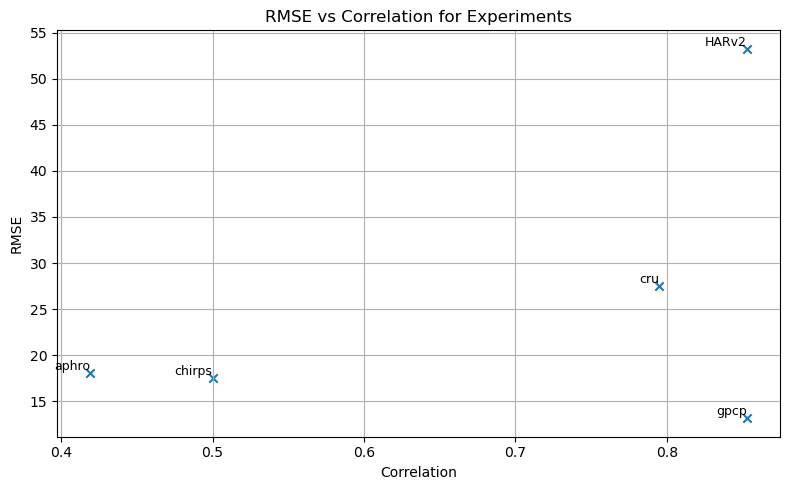

In [62]:
labels=modelList[1:]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(rList, rmseList, marker="x")

# Add experiment labels next to each point
for x, y, label in zip(rList, rmseList, labels):
    ax.text(x, y, label, fontsize=9, ha="right", va="bottom")

ax.set_xlabel("Correlation")
ax.set_ylabel("RMSE")
ax.set_title("RMSE vs Correlation for Experiments")
ax.grid(True)
fig.tight_layout()

In [63]:
print('JJA')
ts_seasonList=ts_seasonList_JJA

rList=[]
biasList=[]
std_devList=[]
rmseList=[]

pred = ts_seasonList[0]#np.array([2.5, 0.0, 2.1, 7.8])
for i in np.arange(1,len(ts_seasonList),1):
    obs =ts_seasonList[i] 
    corr_coef, _ = pearsonr(obs, pred)
    bias = np.mean(pred - obs)
    std_dev = np.std(pred - obs)
    rmse = np.sqrt(np.mean((pred - obs) ** 2))
    rList.append(round(corr_coef,3))
    biasList.append(round(float(bias.values),3))
    std_devList.append(round(float(std_dev.values),3))
    rmseList.append(round(float(rmse.values),3))

modelResList=zip(modelList[1:],resList[1:])
# Create the DataFrame
df = pd.DataFrame({
    "Model_Res": modelResList,
    "Corr": rList,
    "Bias": biasList,
    "Std_Dev": std_devList,
    "RMSE": rmseList
})

# Display the DataFrame

print(df)

JJA
               Model_Res   Corr    Bias  Std_Dev    RMSE
0   (aphro, 0.25°x0.25°)  0.193   0.933   12.286  12.321
1      (gpcp, 1.0°x1.0°)  0.816   5.431    2.678   6.055
2       (cru, 0.5°x0.5°)  0.687   8.282    3.205   8.881
3  (chirps, 0.05°x0.05°)  0.663   3.155    3.348   4.600
4     (HARv2, 10kmx10km)  0.924 -20.747    6.270  21.674


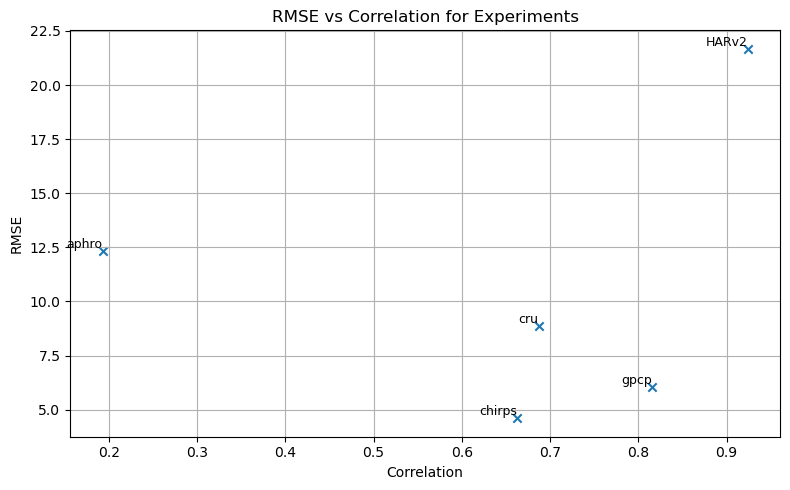

In [64]:
labels=modelList[1:]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(rList, rmseList, marker="x")

# Add experiment labels next to each point
for x, y, label in zip(rList, rmseList, labels):
    ax.text(x, y, label, fontsize=9, ha="right", va="bottom")

ax.set_xlabel("Correlation")
ax.set_ylabel("RMSE")
ax.set_title("RMSE vs Correlation for Experiments")
ax.grid(True)
fig.tight_layout()

In [65]:
print('SON')
ts_seasonList=ts_seasonList_SON

rList=[]
biasList=[]
std_devList=[]
rmseList=[]

pred = ts_seasonList[0]#np.array([2.5, 0.0, 2.1, 7.8])
for i in np.arange(1,len(ts_seasonList),1):
    obs =ts_seasonList[i] 
    corr_coef, _ = pearsonr(obs, pred)
    bias = np.mean(pred - obs)
    std_dev = np.std(pred - obs)
    rmse = np.sqrt(np.mean((pred - obs) ** 2))
    rList.append(round(corr_coef,3))
    biasList.append(round(float(bias.values),3))
    std_devList.append(round(float(std_dev.values),3))
    rmseList.append(round(float(rmse.values),3))

modelResList=zip(modelList[1:],resList[1:])
# Create the DataFrame
df = pd.DataFrame({
    "Model_Res": modelResList,
    "Corr": rList,
    "Bias": biasList,
    "Std_Dev": std_devList,
    "RMSE": rmseList
})

# Display the DataFrame

print(df)

SON
               Model_Res   Corr    Bias  Std_Dev    RMSE
0   (aphro, 0.25°x0.25°)  0.465  -2.083    9.021   9.258
1      (gpcp, 1.0°x1.0°)  0.846  -0.293    3.793   3.804
2       (cru, 0.5°x0.5°)  0.770  -5.745    6.414   8.610
3  (chirps, 0.05°x0.05°)  0.733  -0.947    3.779   3.896
4     (HARv2, 10kmx10km)  0.890 -20.218    7.822  21.678


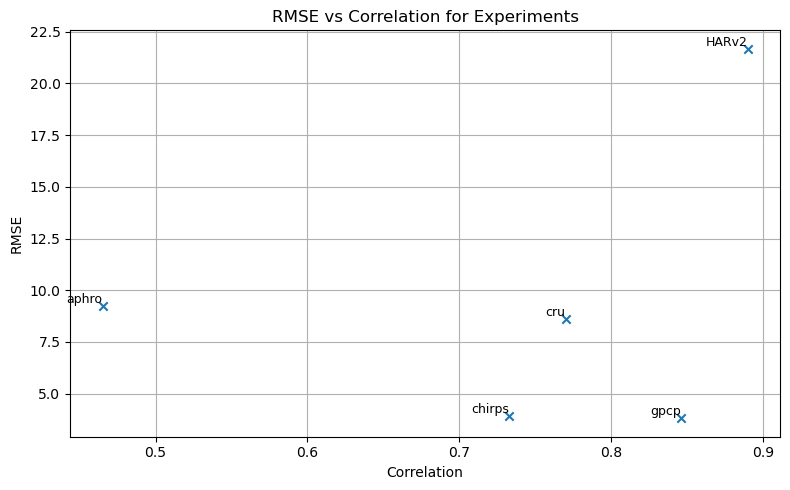

In [66]:
labels=modelList[1:]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(rList, rmseList, marker="x")

# Add experiment labels next to each point
for x, y, label in zip(rList, rmseList, labels):
    ax.text(x, y, label, fontsize=9, ha="right", va="bottom")

ax.set_xlabel("Correlation")
ax.set_ylabel("RMSE")
ax.set_title("RMSE vs Correlation for Experiments")
ax.grid(True)
fig.tight_layout()